# Bollinger Bands Mean Reversion Strategy on the S&P 500

## Project Objective

The objective of this project is to design, implement, and evaluate a **mean reversion trading strategy** using **Bollinger Bands** on the **S&P 500 Index (SPX)**.

This notebook demonstrates the complete workflow of a quantitative trading strategy:

1. Data acquisition and preprocessing
2. Feature engineering using Bollinger Bands
3. Signal generation for a mean reversion strategy
4. Strategy backtesting
5. Performance comparison against a buy-and-hold benchmark
6. Visualization and evaluation of results

The notebook is structured to allow an analyst to understand both the **financial reasoning** and the **technical implementation** of the strategy.

---

## Research Question

Can a Bollinger Bands-based mean reversion strategy outperform a passive buy-and-hold investment in the S&P 500?

To answer this question, we evaluate the strategy on historical daily market data and compare its cumulative returns to the underlying benchmark index.

In [1]:
# Import libraries used throughout the notebook
# pandas — DataFrame handling, rolling windows, time-series operations
# numpy — numerical operations
# matplotlib.pyplot (aliased as pt) — plotting the bands and cumulative returns
# yfinance — downloading historical S&P 500 (^SPX) price data
# backtrader — institutional-style backtesting engine (Cerebro) used at the end
!pip install backtrader
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
import yfinance as yf
import backtrader as bt

# Bollinger Bands

## What Are Bollinger Bands?

Bollinger Bands are a **technical analysis indicator** developed by John Bollinger.

They consist of:

1. **Middle Band** → Moving Average (MA)
2. **Upper Band** → MA + k × Standard Deviation
3. **Lower Band** → MA − k × Standard Deviation

The indicator measures how far prices deviate from their historical average.

### Interpretation

- When price reaches the **upper band**, the market may be considered **overbought**.
- When price reaches the **lower band**, the market may be considered **oversold**.

This creates opportunities for **mean reversion strategies**, where prices are expected to revert toward their historical average.

In this project:

- Moving Average Window = **20 days**
- Standard Deviation Multiplier = **2**

These are commonly used parameters in financial markets.

In [2]:
# Function: compute Bollinger Bands on a price DataFrame
# Inputs:
#   data    — DataFrame containing at least a 'Close' column
#   window  — rolling window length for the moving average (default 20)
#   num_std — standard-deviation multiplier for band width (default 2)
# Steps:
#   1. Copy the input DataFrame so the original is not mutated.
#   2. Compute 'MA'  = rolling mean of 'Close' over `window` periods.
#   3. Compute 'STD' = rolling standard deviation of 'Close' over `window` periods.
#   4. Compute 'Upper' = MA + num_std * STD.
#   5. Compute 'Lower' = MA - num_std * STD.
#   6. Return the augmented DataFrame.

def bollinger_bands(data, window=20, num_std=2):
    df = data.copy()

    df['MA'] = df['Close'].rolling(window).mean() 
    #defines a 20 row sliding window over the Close series and averages each window into one value
    
    df['STD'] = df['Close'].rolling(window).std()
    #is the same sliding window over the Close series, but meaasures how spread out the Closes are within each window 

    df['Upper'] = df['MA'] + num_std * df['STD']
    df['Lower'] = df['MA'] - num_std * df['STD']

    return df

# 4. Mean Reversion Trading Strategy

## Trading Logic

The strategy follows a **mean reversion hypothesis**:

> Extreme deviations from the moving average are temporary and prices tend to revert toward their mean.

### Entry Rules

**Long Position (Buy)**

A long position is entered when:

\[
Price < Lower\ Bollinger\ Band
\]

Interpretation:
The asset is considered temporarily oversold.

---

**Short Position (Sell)**

A short position is entered when:

\[
Price > Upper\ Bollinger\ Band
\]

Interpretation:
The asset is considered temporarily overbought.

---

### Exit Rule

Positions are closed once price returns to the moving average.

This represents the expected “reversion” toward equilibrium.

In [3]:
# Function: generate mean-reversion trading signals from Bollinger Bands
# Convention: 'Position' column holds 1 (long), -1 (short), or 0 (flat).
# Steps:
#   1. Copy the input DataFrame to avoid mutating caller data.
#   2. Initialise a 'Position' column filled with 0 (no position).
#   3. Entry rule — go LONG (Position = 1) when Close < Lower band (oversold).
#   4. Entry rule — go SHORT (Position = -1) when Close > Upper band (overbought).
#   5. Exit rule — close LONG (Position = 0) when Close >= MA (reverted up to mean).
#   6. Exit rule — close SHORT (Position = 0) when Close <= MA (reverted down to mean).
#   7. Forward-fill positions so a trade is held from entry until the next exit
#      signal. Use .replace(0, method='ffill') then .fillna(0) for leading NaNs.
#   8. Return the DataFrame with the 'Position' column populated.

#1
def mean_revis_bb_strategy(df):
    #1
    df = df.copy()

    #2
    df['Position'] = 0  # 1 = long, -1 = short

    # Entry signals
    #3
    df.loc[df['Close'] < df['Lower'], 'Position'] = 1

    #4
    df.loc[df['Close'] > df['Upper'], 'Position'] = -1

    # Exit signals (mean reversion)
    #5
    df.loc[(df['Close'] >= df['MA']) & (df['Position'] == 1), 'Position'] = 0
    #6
    df.loc[(df['Close'] <= df['MA']) & (df['Position'] == -1), 'Position'] = 0

    # Forward fill positions (hold until exit)(take the last known value)
    df['Position'] = df['Position'].replace(to_replace=0, method='ffill').fillna(0)

    return df

# Backtesting Framework

Backtesting evaluates how the strategy would have performed historically.

The process includes:

1. Calculating market returns
2. Computing strategy returns based on positions
3. Comparing cumulative performance against buy-and-hold

### Benchmark

The benchmark used is a passive investment in the S&P 500 index.

This allows us to determine whether the strategy adds value relative to simply holding the market.

In [4]:
# Function: backtest the strategy by computing returns and cumulative growth
# Steps:
#   1. Copy the DataFrame to avoid mutating caller data.
#   2. 'Returns' — daily simple return of Close, via .pct_change().
#   3. 'Strategy_Returns' — yesterday's position times today's return.
#      Shift Position by 1 to avoid look-ahead bias (a position taken at
#      close of day t-1 earns the return realised on day t).
#   4. 'Cumulative_Market'   — (1 + Returns).cumprod(), buy-and-hold benchmark.
#   5. 'Cumulative_Strategy' — (1 + Strategy_Returns).cumprod(), strategy curve.
#   6. Return the enriched DataFrame.


def backtest(df):
    df = df.copy()

    #2 (todays close vs yestedays close as a percentage)
    df['Returns'] = df['Close'].pct_change()

    #3 (percentage * if it was positive or not)   
    df['Strategy_Returns'] = df['Position'].shift(1) * df['Returns']

    #4 the daily returns compounded
    df['Cumulative_Market'] = (1 + df['Returns']).cumprod()

    #5
    df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()

    return df

# Data Collection

We use **daily historical prices** of the **S&P 500 Index (^SPX)**.

## Why Daily Data?

Daily prices are chosen for several reasons:

### 1. Strategy Horizon
Bollinger Band mean reversion strategies typically operate on **short- to medium-term horizons**, where deviations from the moving average occur over several trading days.

### 2. Noise Reduction
Intraday or high-frequency data contains substantial market microstructure noise, bid-ask spread effects, and execution frictions. Daily data provides a cleaner representation of underlying market trends.

### 3. Computational Simplicity
Daily data reduces complexity while still allowing meaningful evaluation of the trading logic.

### 4. Suitable for Proof-of-Concept
For a first implementation of a quantitative strategy, daily data provides an interpretable and computationally efficient framework.

---

## Why the S&P 500?

The **S&P 500 Index** is selected because:

- It is a broad representation of the U.S. equity market.
- It is highly liquid and widely studied.
- Mean reversion behaviour has been historically observed in major equity indices.
- It provides a strong benchmark for comparing systematic strategies.

In [5]:
# Download S&P 500 daily OHLCV data from Yahoo Finance
# Steps:
#   1. Call yf.download with ticker "^SPX" and date range 2020-01-01 to 2026-05-01.
#   2. yfinance returns a MultiIndex column DataFrame (Price level, Ticker level).
#      Flatten it by keeping only the top level: SPX.columns.get_level_values(0).
#   3. Display the DataFrame (last expression in the cell) to inspect the result.

#1
SnP = yf.download("^SPX", start="2020-01-01", end="2026-05-01")

#2
SnP.columns = SnP.columns.get_level_values(0)
#3
SnP


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2026-04-24,7165.080078,7168.589844,7112.819824,7136.479980,4608830000
2026-04-27,7173.910156,7178.740234,7146.720215,7152.720215,4783750000
2026-04-28,7138.799805,7152.520020,7115.169922,7133.740234,4900650000


In [6]:
# Persist the downloaded data to disk so re-runs do not re-hit the network.
# Use the Parquet format (compact, typed, fast to reload).

SnP.to_parquet("spx_data.parquet")
# Data is saved to folder

In [7]:
# Reload the saved data from disk and prepare it for analysis
# Steps:
#   1. Read 'spx_data.parquet' into a DataFrame `df`.
#   2. Ensure the index is a DatetimeIndex via pd.to_datetime(df.index).
#   3. Keep only the standard OHLCV columns in a fixed order:
#      ['Open', 'High', 'Low', 'Close', 'Volume'].
#   4. Drop any rows that contain NaN values (df.dropna()).
#   5. Show the first rows with df.head() to verify the load.

df = pd.read_parquet("spx_data.parquet")
df.index = pd.to_datetime(df.index)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df = df.dropna()
df.head()

# Reading the data

Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3459930000
2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3484700000
2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3702460000
2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3435910000
2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3726840000


In [8]:
# Run the full strategy pipeline on the loaded DataFrame
# Steps:
#   1. Compute Bollinger Bands (window=20, num_std=2) — adds MA, STD, Upper, Lower.
#   2. Generate mean-reversion signals — adds the 'Position' column.
#   3. Backtest — adds Returns, Strategy_Returns, Cumulative_Market,
#      Cumulative_Strategy.
#   4. Print the tail of the DataFrame to inspect the final state.

df = bollinger_bands(df, window=20, num_std=2)
df = mean_revis_bb_strategy(df)
df = backtest(df)

print(df.tail())




Price              Open         High          Low        Close      Volume  \
Date                                                                         
2026-04-24  7136.479980  7168.589844  7112.819824  7165.080078  4608830000   
2026-04-27  7152.720215  7178.740234  7146.720215  7173.910156  4783750000   
2026-04-28  7133.740234  7152.520020  7115.169922  7138.799805  4900650000   
2026-04-29  7131.609863  7145.629883  7107.859863  7135.950195  5123100000   
2026-04-30  7161.750000  7219.830078  7126.149902  7209.009766  5723790000   

Price                MA         STD        Upper        Lower  Position  \
Date                                                                      
2026-04-24  6834.029028  268.524162  7371.077352  6296.980704        -1   
2026-04-27  6874.282031  255.128548  7384.539127  6364.024935        -1   
2026-04-28  6914.036011  228.678950  7371.393910  6456.678112        -1   
2026-04-29  6944.407520  214.692183  7373.791885  6515.023154        -1   
202

/var/folders/d0/739ckpb535xfggf1xgnnd49h0000gn/T/ipykernel_73590/2834701693.py:36: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Position'].replace(to_replace=0, method='ffill').fillna(0)


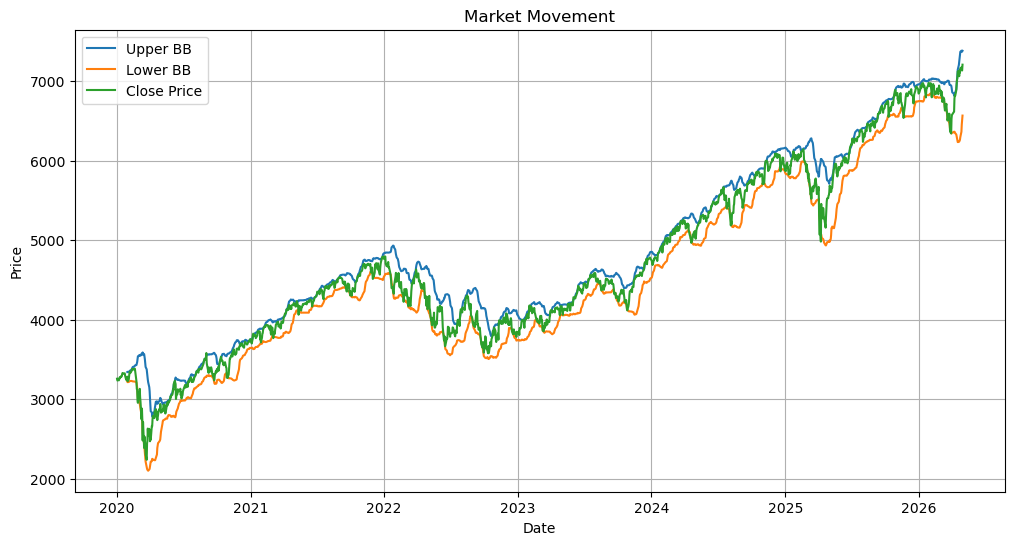

In [9]:
# Plot: price action with the Bollinger Bands overlaid
# Steps:
#   1. Create a matplotlib figure sized 12 x 6 inches.
#   2. Plot the Upper band, Lower band, and Close price against the date index;
#      give each line a descriptive label for the legend.
#   3. Add a title t Movement") and axis labels ("Date", "Price").
#   4. Show legend and grid.
#   5. Render the figure with pt.show().

pt.figure(figsize=(12, 6))

pt.plot(df.index, df['Upper'], label='Upper BB')
pt.plot(df.index, df['Lower'], label='Lower BB')
pt.plot(df.index, df['Close'], label='Close Price')

pt.title("Market Movement")
pt.xlabel("Date")
pt.ylabel("Price")

pt.legend()
pt.grid()
pt.show()
         

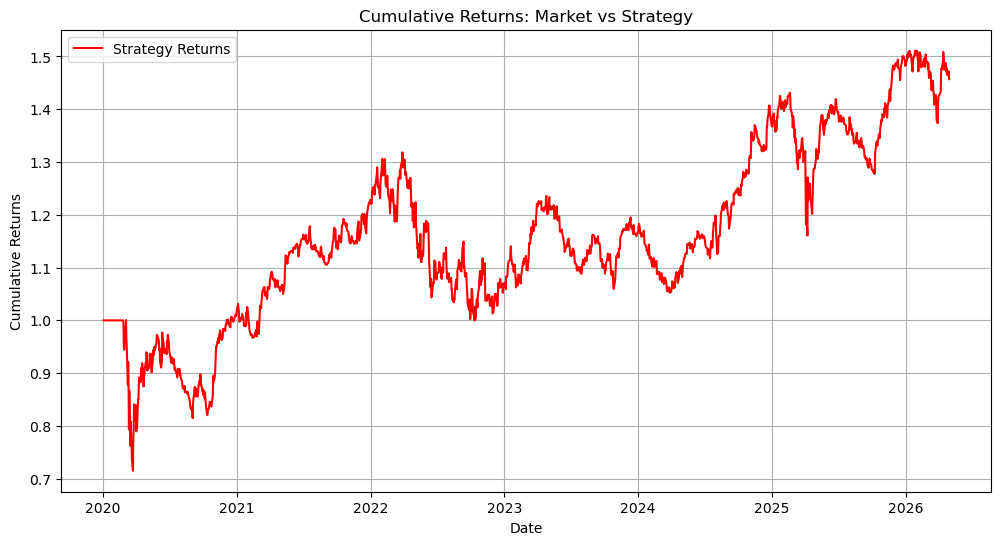

In [10]:
# Plot: cumulative strategy returns over time
# Steps:
#   1. Create a 12 x 6 figure.
#   2. Plot 'Cumulative_Strategy' against the date index, labelled
#      "Strategy Returns".
#   3. Title "Cumulative Returns: Market vs Strategy", x-axis "Date",
#      y-axis "Cumulative Returns".
#   4. Add legend and grid; render with pt.show().
# Note: although the title mentions Market vs Strategy, only the strategy
# curve is plotted in this cell. To also compare against buy-and-hold, add
# pt.plot(df.index, df['Cumulative_Market'], label='Market Returns').

pt.figure(figsize=(12, 6))

pt.plot(df.index, df['Cumulative_Strategy'], label='Strategy Returns', color='red')

pt.title("Cumulative Returns: Market vs Strategy")
pt.xlabel("Date")
pt.ylabel("Cumulative Returns")

pt.legend()
pt.grid()
pt.show()

# Next Step: Institutional Backtesting Framework

To improve robustness, the strategy is migrated into the **Backtrader framework using the Cerebro engine**.

Advantages include:

- Automated strategy execution
- Built-in analytics
- Performance statistics
- Benchmark comparison
- Portfolio accounting
- Trade logs
- Professional visualizations

This would align the implementation closer to industry quantitative research workflows.

In [16]:
# Migrate the strategy to the Backtrader framework (Cerebro engine).
#
# Step A — Wrap the prepared pandas DataFrame `df` as a Backtrader data feed
#          using bt.feeds.PandasData(dataname=df).
#
# Step B — Define a Strategy subclass `BollingerMeanReversion`:
#   * params: ('period', 20), ('devfactor', 2) — Bollinger window and std multiplier.
#   * __init__:
#       - Attach bt.indicators.BollingerBands to self.data.close using
#         period=self.params.period and devfactor=self.params.devfactor;
#         this exposes .lines.top, .lines.mid, .lines.bot.
#       - Initialise self.order = None (used to track pending orders).
#   * next() — runs on every bar:
#       - If an order is pending (self.order), return early.
#       - If no open position:
#           * LONG entry  — if close < lower band, call self.buy()  and store the order.
#           * SHORT entry — elif close > upper band, call self.sell() and store the order.
#       - If currently LONG (self.position.size > 0):
#           * Exit when close >= middle band: self.close().
#       - If currently SHORT (self.position.size < 0):
#           * Exit when close <= middle band: self.close().
#   * notify_order(order) — when order.status is Completed, clear self.order
#     so new orders can be placed.
#
# Step C — Configure Cerebro:
#   1. cerebro = bt.Cerebro()
#   2. cerebro.addstrategy(BollingerMeanReversion)
#   3. cerebro.adddata(data)
#   4. Starting capital: cerebro.broker.setcash(100000)
#   5. Commission: cerebro.broker.setcommission(commission=0.001)  (10 bps per trade)
#   6. Position sizing: cerebro.addsizer(bt.sizers.FixedSize, stake=17)
#   7. Attach analyzers with names so they can be retrieved after the run:
#        - SharpeRatio    -> _name='sharpe'
#        - DrawDown       -> _name='drawdown'
#        - Returns        -> _name='returns'
#        - TradeAnalyzer  -> _name='trades'

#Step A (so Backtrader can walk it bar by bar.)
data = bt.feeds.PandasData(dataname=df)

#Step B
class BollingerMeanReversion(bt.Strategy):
    params = (('period', 20),('devfactor', 2))

    def __init__(self):
        self.bbands = bt.indicators.BollingerBands(
            self.data.close,
            period=self.params.period,
            devfactor=self.params.devfactor)
        self.order = None 

    def next(self):
        if self.order:
            return

        if not self.position:
            if self.data.close[0] < self.bbands.lines.bot[0]:
                self.order = self.buy()
            elif self.data.close[0] > self.bbands.lines.top[0]:
                self.order = self.sell()

        elif self.position.size < 0:
            if self.data.close[0] <= self.bbands.lines.mid[0]:
                self.order = self.close()

        elif self.position.size > 0:
            if self.data.close[0] >= self.bbands.lines.mid[0]:
                self.order = self.close()

    def notify_order(self, order):
        if order.status in [order.Completed]:
            self.order = None


#Step C
cerebro = bt.Cerebro()
cerebro.addstrategy(BollingerMeanReversion)
cerebro.adddata(data)

#Starting capital: 
cerebro.broker.setcash(100000)

#Commission: realism that pandas backtest ignored entirely. buy and sells cost money, which drags on returns
cerebro.broker.setcommission(commission=0.001)

#Position sizing: (always trade 17 units)-> pandas assumed always 100%
cerebro.addsizer(bt.sizers.FixedSize, stake=17)


# Sharpe Ratio
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')

# Drawdown (worst peak to through drop)
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

# Returns
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')

# Trade statistics (per trade stats)
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')



    


In [17]:
# Run the Cerebro backtest and report results
# Steps:
#   1. results = cerebro.run() — execute the backtest; returns a list of
#      strategy instances (one per added strategy).
#   2. strategy = results[0] — take the single BollingerMeanReversion instance.
#   3. Print starting portfolio value ($100,000, fixed by setcash above).
#   4. Print final portfolio value via cerebro.broker.getvalue(),
#      formatted with thousands separators and 2 decimals.
#   5. Sharpe — strategy.analyzers.sharpe.get_analysis() returns a dict-like
#      object; print it directly.
#   6. Drawdown — strategy.analyzers.drawdown.get_analysis(); print
#      drawdown.max.drawdown as a percentage with 2 decimals.
#   7. Returns — strategy.analyzers.returns.get_analysis(); print
#      returns['rtot'] * 100 as a percentage with 2 decimals (total return).

results = cerebro.run()
strategy = results[0]
print("Starting Portfolio Value: $100,000")
print(f"Final Portfolio Value: ${cerebro.broker.getvalue():,.2f}")

print("\nSharpe Ratio:")
print(strategy.analyzers.sharpe.get_analysis())


drawdown = strategy.analyzers.drawdown.get_analysis()
print("\nMaximum Drawdown:")
print(f"{drawdown.max.drawdown:.2f}%")


returns = strategy.analyzers.returns.get_analysis()
print("\nTotal Return:")
print(f"{returns['rtot']*100:.2f}%")




Starting Portfolio Value: $100,000
Final Portfolio Value: $104,502.97

Sharpe Ratio:
OrderedDict({'sharperatio': -0.13778570542235924})

Maximum Drawdown:
15.40%

Total Return:
4.40%
